Doug  [9:46 AM]
Can you please compare and evaluate LiveOcean boundary condition files created by production after the change to cas7_t1_x11ab and from the files that Kate recently provided:

/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2024m08d26.nc   
/results/forcing/LiveOcean/cas7_t1_x11ab/boundary_conditions/LiveOcean_v201905_y2024m08d26.nc

In [6]:
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
old = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2024m08d26.nc')
new = xr.open_dataset('/results/forcing/LiveOcean/cas7_t1_x11ab/boundary_conditions/LiveOcean_v201905_y2024m08d26.nc')

In [3]:
old

<xarray.Dataset>
Dimensions:       (time_counter: 1, deptht: 40, yb: 1, xbT: 950)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2024-08-27T12:00:00
  * deptht        (deptht) float64 0.5 1.5 2.5 3.5 ... 360.7 387.6 414.5 441.5
  * yb            (yb) int64 1
  * xbT           (xbT) int64 0 1 2 3 4 5 6 7 ... 943 944 945 946 947 948 949
Data variables:
    vosaline      (time_counter, deptht, yb, xbT) float64 ...
    votemper      (time_counter, deptht, yb, xbT) float64 ...
    NO3           (time_counter, deptht, yb, xbT) float64 ...
    Si            (time_counter, deptht, yb, xbT) float64 ...
    OXY           (time_counter, deptht, yb, xbT) float64 ...
    DIC           (time_counter, deptht, yb, xbT) float64 ...
    TA            (time_counter, deptht, yb, xbT) float64 ...
Attributes:
    acknowledgements:      Live Ocean http://faculty.washington.edu/pmacc/LO/...
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          Salish Sea MEOPAR Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    summary:               Temperature, Salinity, Nitrate, Oxygen, DIC and TA...
    source:                http://nbviewer.jupyter.org/urls/bitbucket.org/sal...
    history:               [2024-08-26] File creation.

In [14]:
def do_three_plots(old, new, variable):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    old[variable][0, :, 0].plot(ax=axs[0], yincrease=False)
    new[variable][0, :, 0].plot(ax=axs[1], yincrease=False)
    (new[variable][0, :, 0]-old[variable][0, :, 0]).plot(ax=axs[2], yincrease=False)

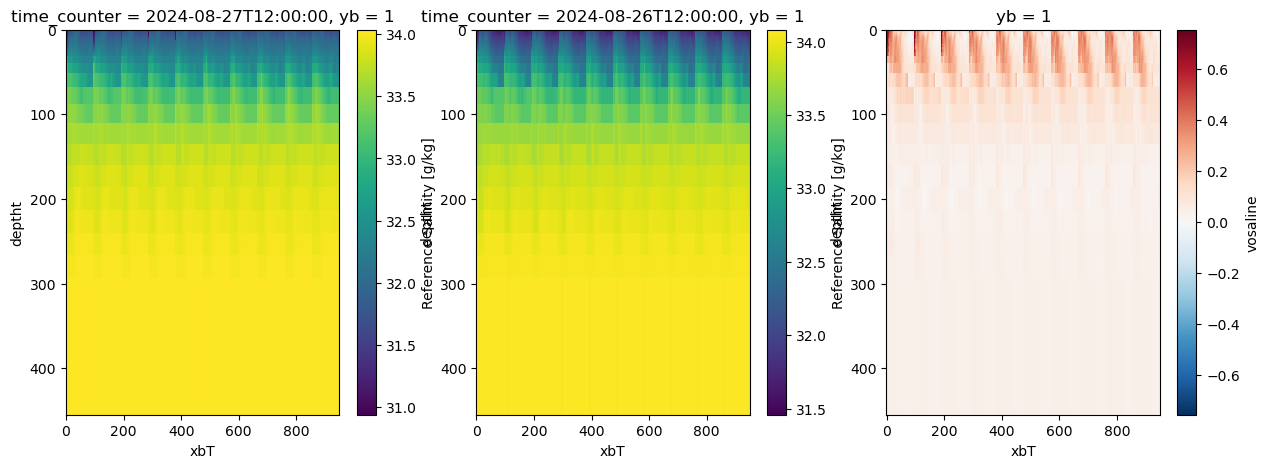

In [15]:
do_three_plots(old, new, 'vosaline')

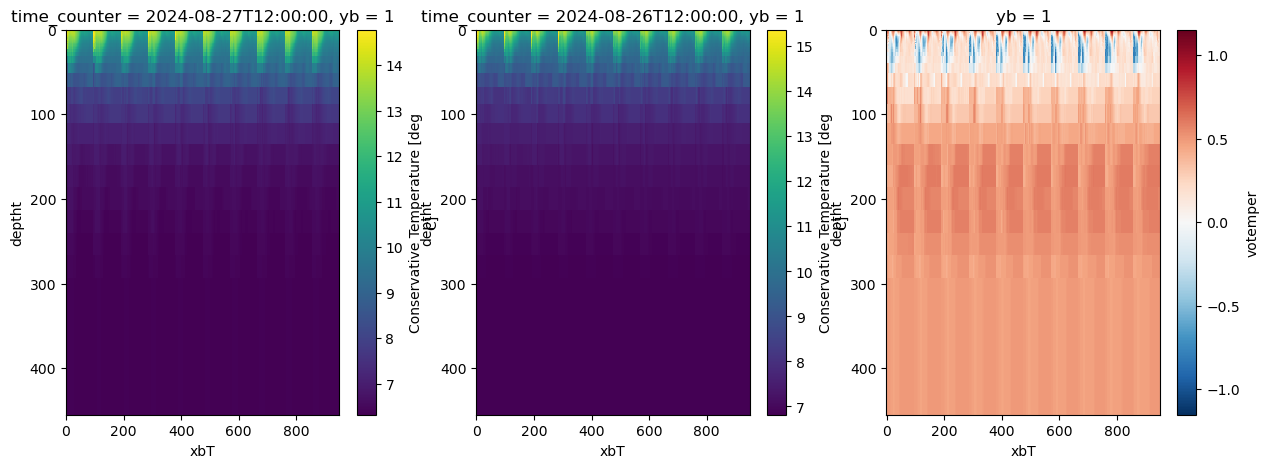

In [16]:
do_three_plots(old, new, 'votemper')

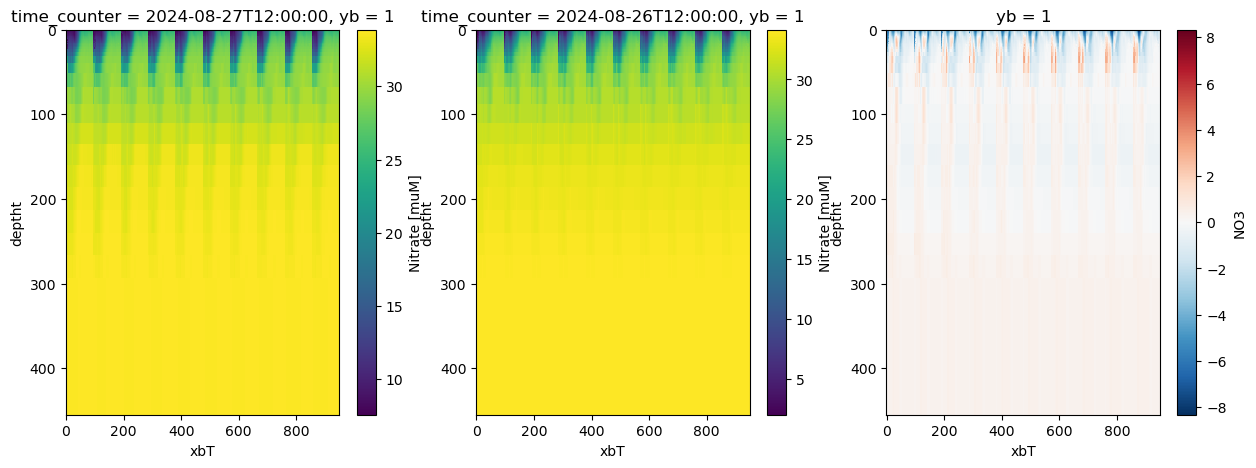

In [17]:
do_three_plots(old, new, 'NO3')

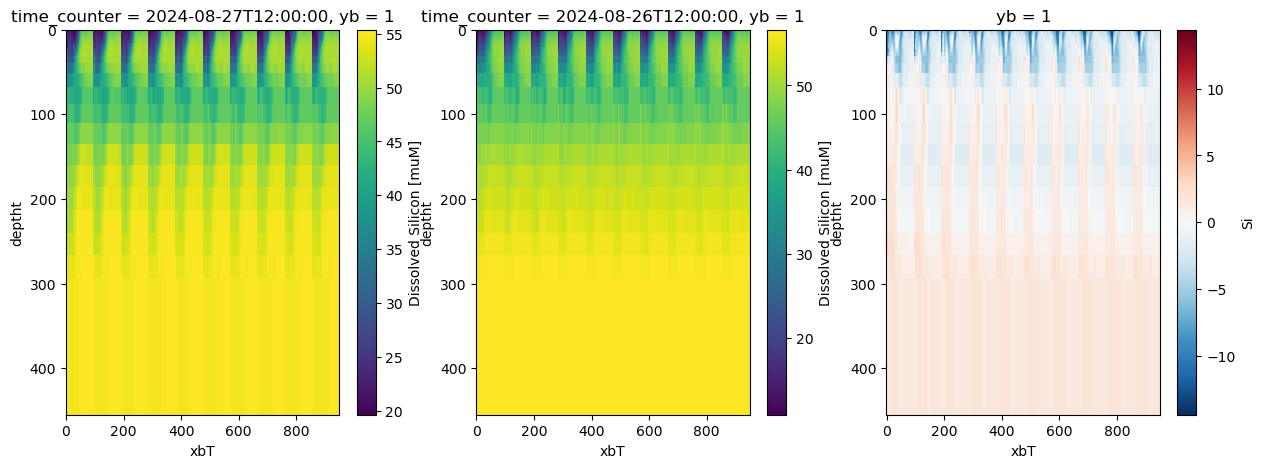

In [18]:
do_three_plots(old, new, 'Si')

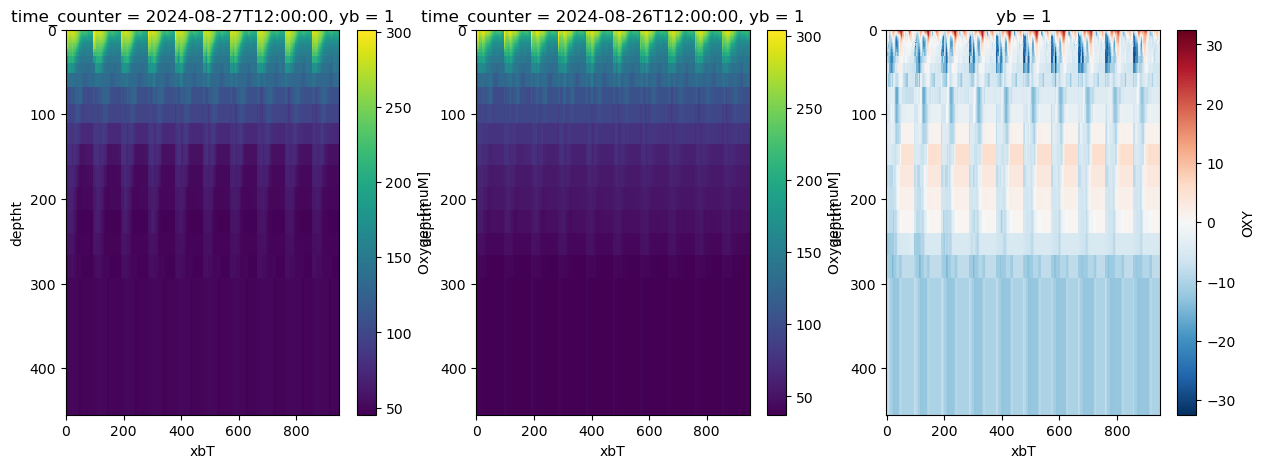

In [20]:
do_three_plots(old, new, 'OXY')

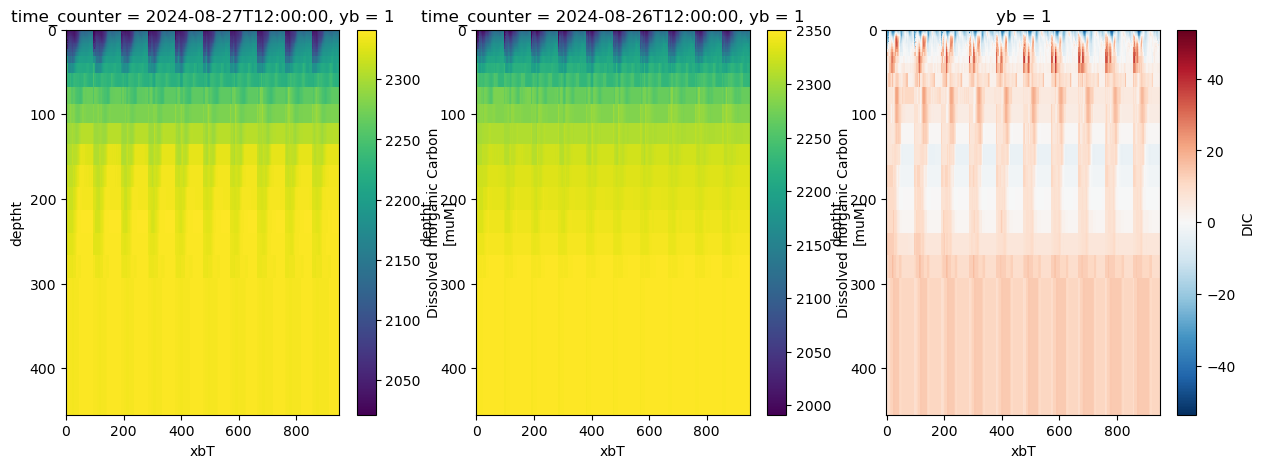

In [21]:
do_three_plots(old, new, 'DIC')

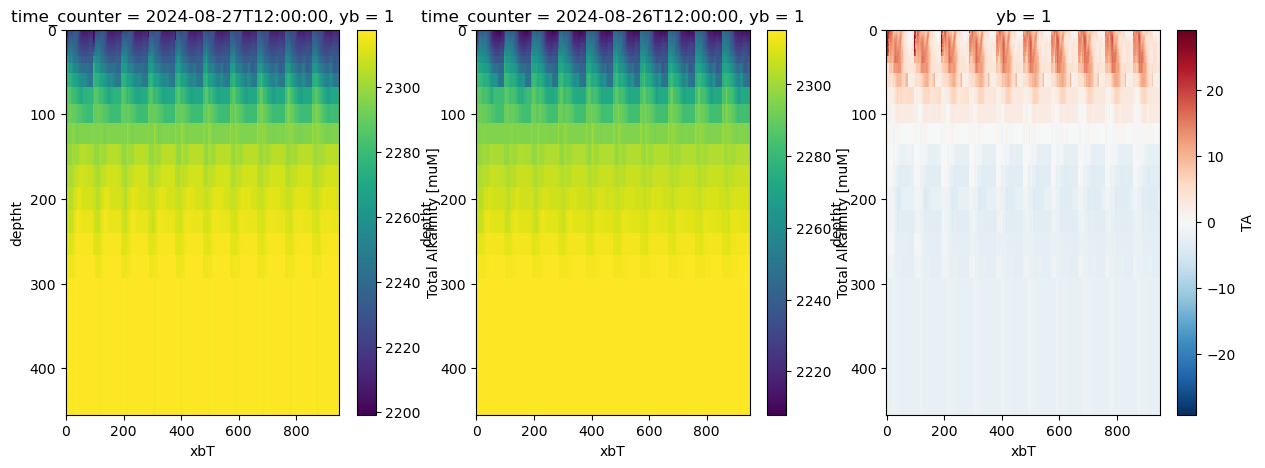

In [22]:
do_three_plots(old, new, 'TA')

In [23]:
old_daybefore = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2024m08d25.nc')


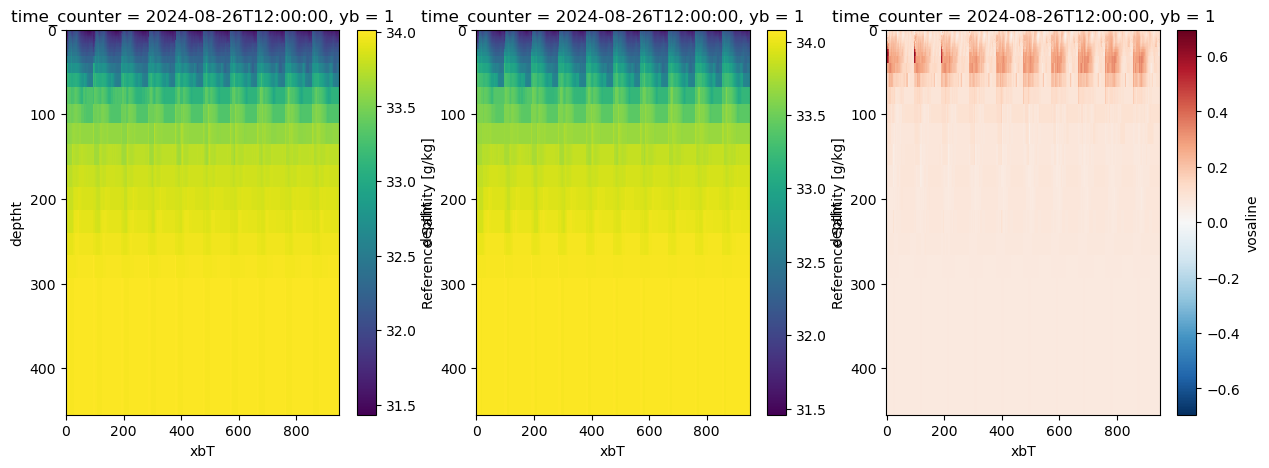

In [24]:
do_three_plots(old_daybefore, new, 'vosaline')

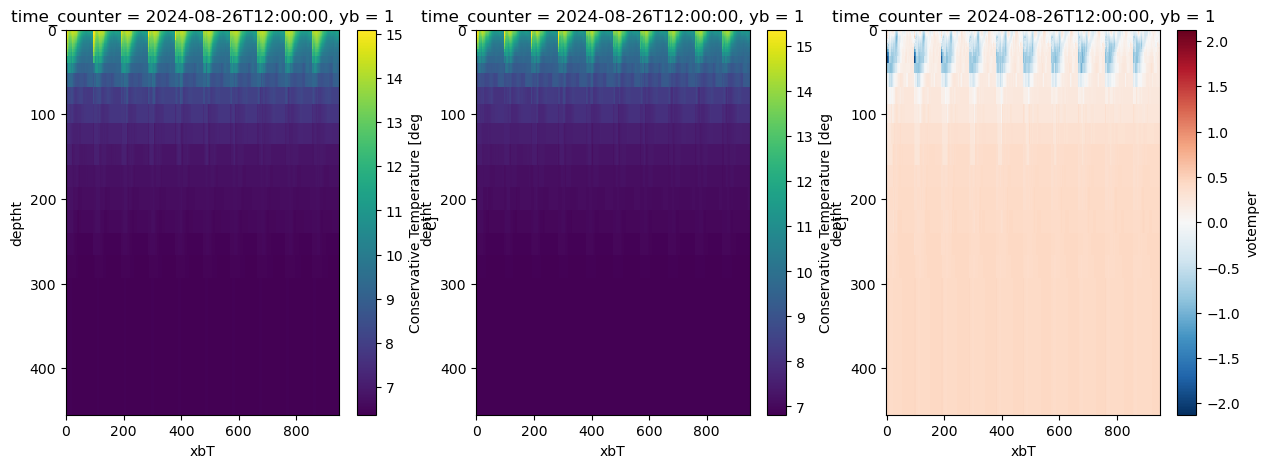

In [25]:
do_three_plots(old_daybefore, new, 'votemper')

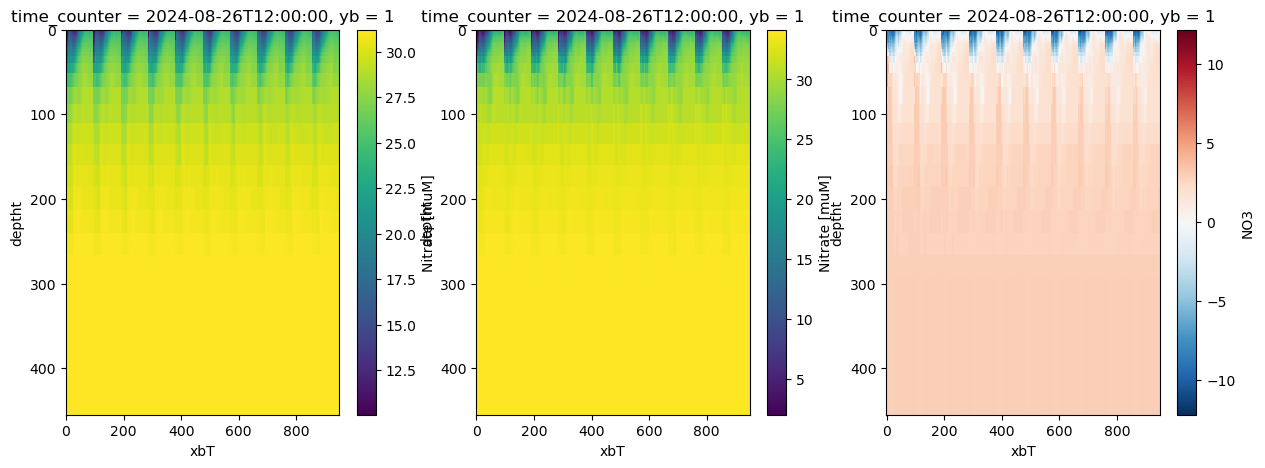

In [26]:
do_three_plots(old_daybefore, new, 'NO3')

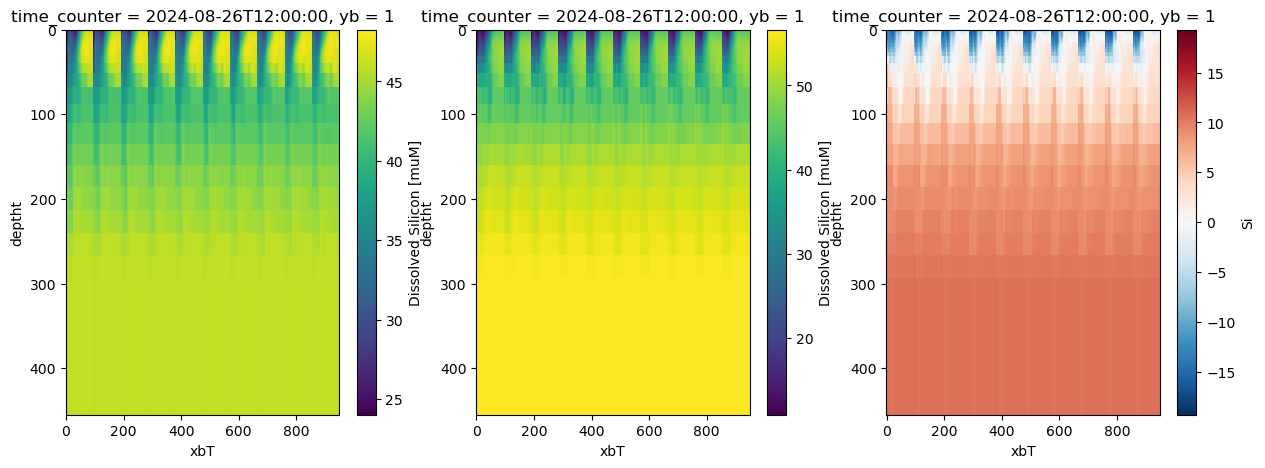

In [27]:
do_three_plots(old_daybefore, new, 'Si')

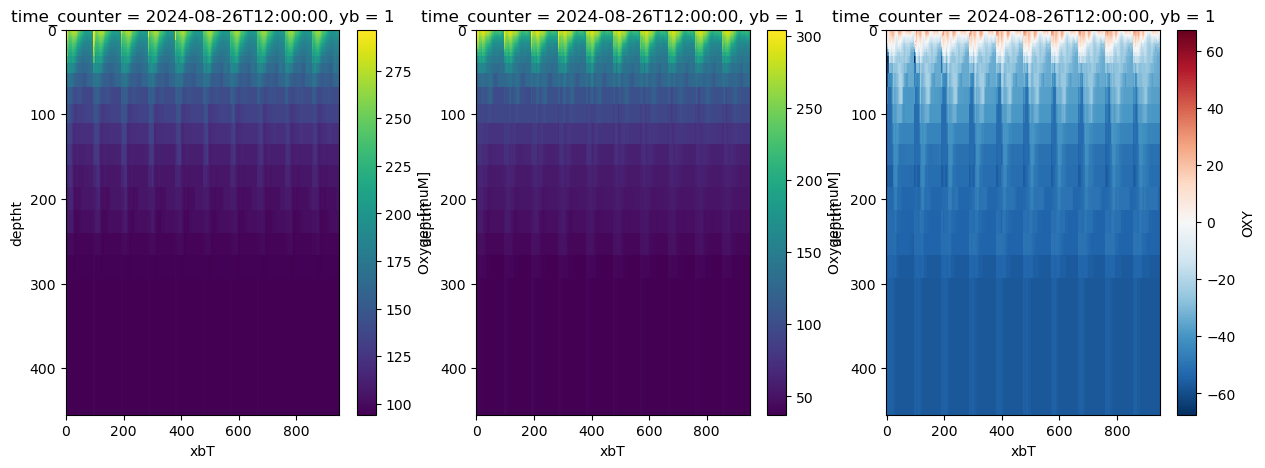

In [28]:
do_three_plots(old_daybefore, new, 'OXY')

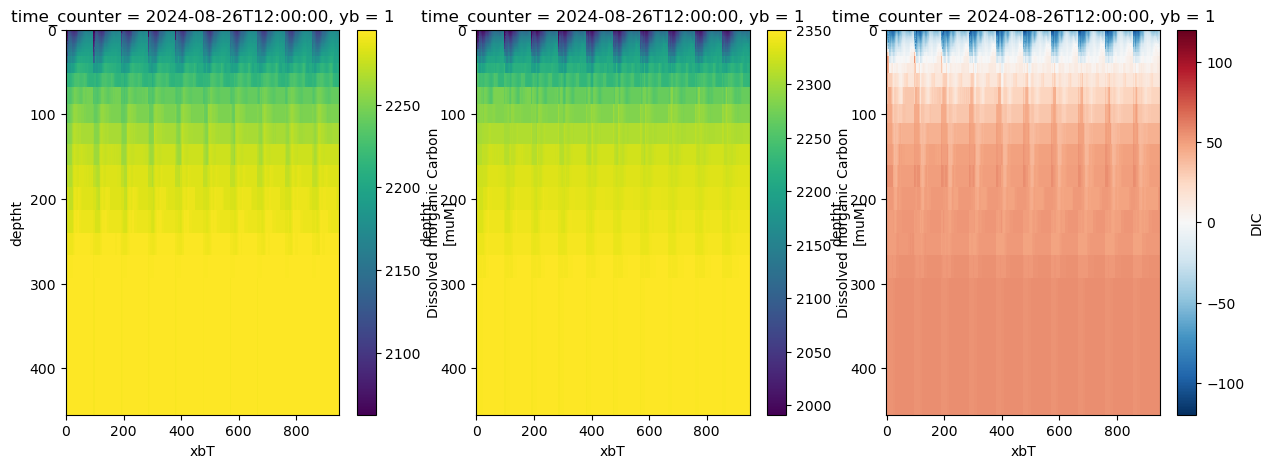

In [29]:
do_three_plots(old_daybefore, new, 'DIC')

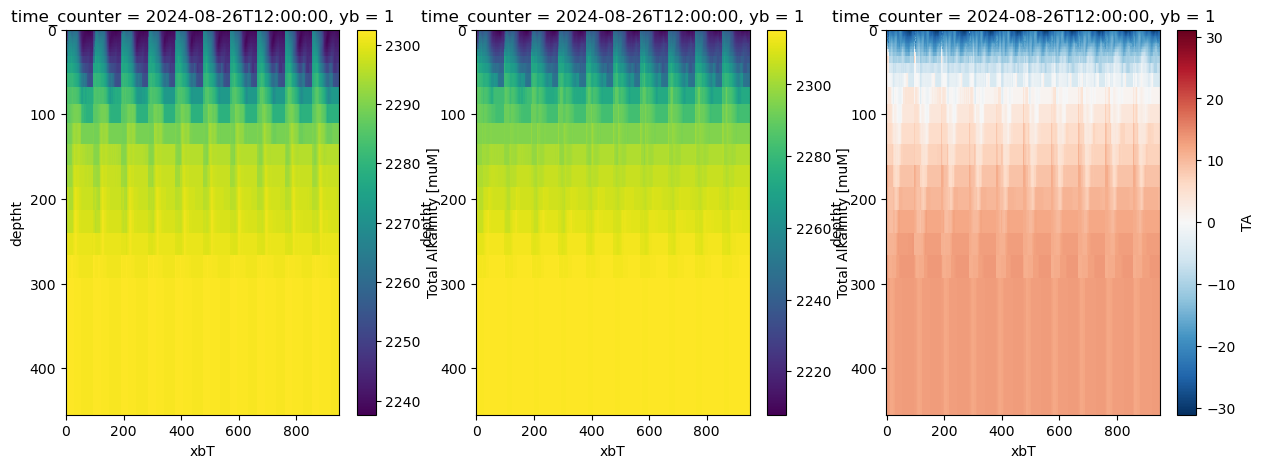

In [30]:
do_three_plots(old_daybefore, new, 'TA')

Interestingly, the day before values (matching the time stamp) don't actually match better!

In [54]:
def plot_comparison(old, old_daybefore, new, variable, iz):
    print ("RMSD, New - Production", (new[variable][0, :, 0, :] - old[variable][0, :, 0, :]).std().values)
    print ("RMSD, New - Production Day Before", (new[variable][0, :, 0, :] 
                                                      - old_daybefore[variable][0, :, 0, :]).std().values)
    fig, ax = plt.subplots(1, 1)
    new[variable][0, iz, 0, :].plot(ax=ax)
    ax2 = ax.twinx()
    (new[variable][0, iz, 0, :] - old[variable][0, iz, 0, :]).plot(ax=ax2, color='tab:orange', label='Production')
    (new[variable][0, iz, 0, :] - old_daybefore[variable][0, iz, 0, :]).plot(ax=ax2, 
                                                                                 color='tab:red', label='Production Day Before')
    ax2.legend();

RMSD, New - Production 0.12666848652866936
RMSD, New - Production Day Before 0.061902330757972766


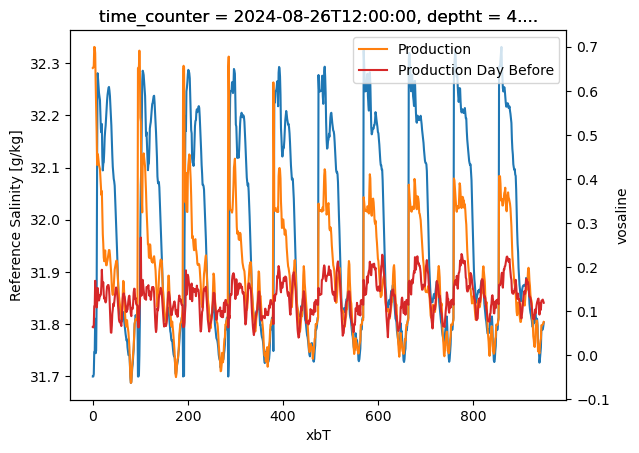

In [55]:
plot_comparison(old, old_daybefore, new, 'vosaline', 4)

RMSD, New - Production 0.3116989194287336
RMSD, New - Production Day Before 0.3424871781085785


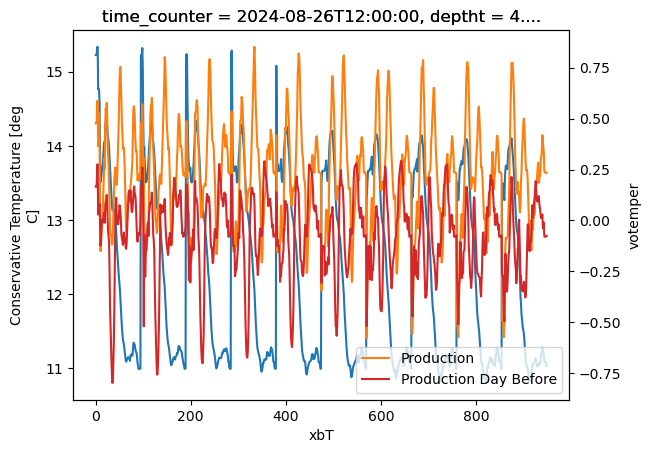

In [56]:
plot_comparison(old, old_daybefore, new, 'votemper', 4)

RMSD, New - Production 1.529237014648873
RMSD, New - Production Day Before 3.60757374416341


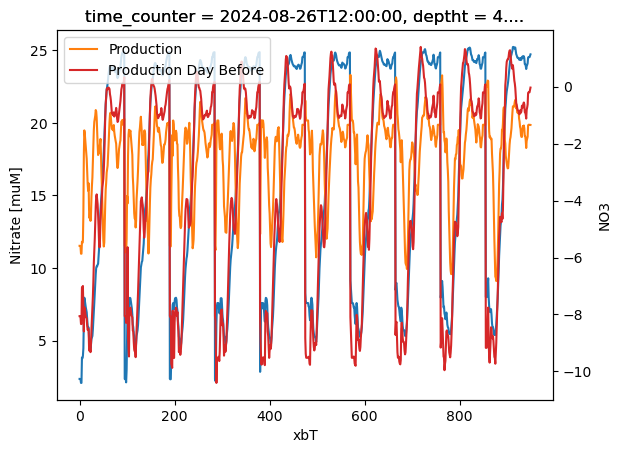

In [57]:
plot_comparison(old, old_daybefore, new, 'NO3', 4)

RMSD, New - Production 3.117188514454539
RMSD, New - Production Day Before 7.9827093827817075


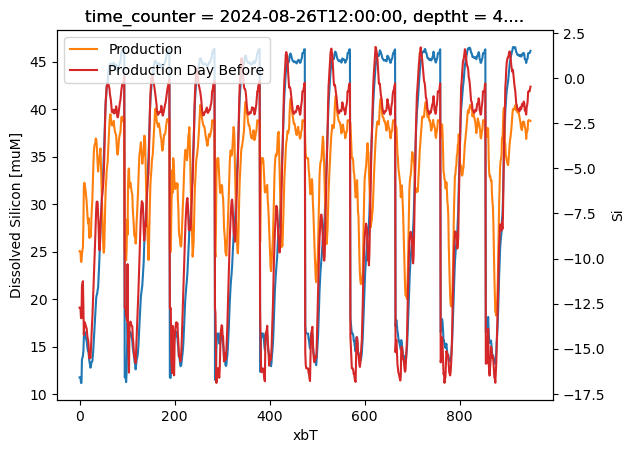

In [58]:
plot_comparison(old, old_daybefore, new, 'Si', 4)

RMSD, New - Production 8.888934659129635
RMSD, New - Production Day Before 27.011565707452306


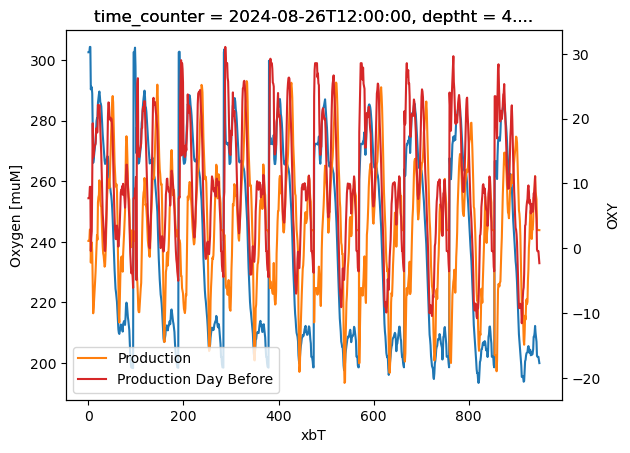

In [59]:
plot_comparison(old, old_daybefore, new, 'OXY', 4)

RMSD, New - Production 12.113870222735754
RMSD, New - Production Day Before 46.57842219954406


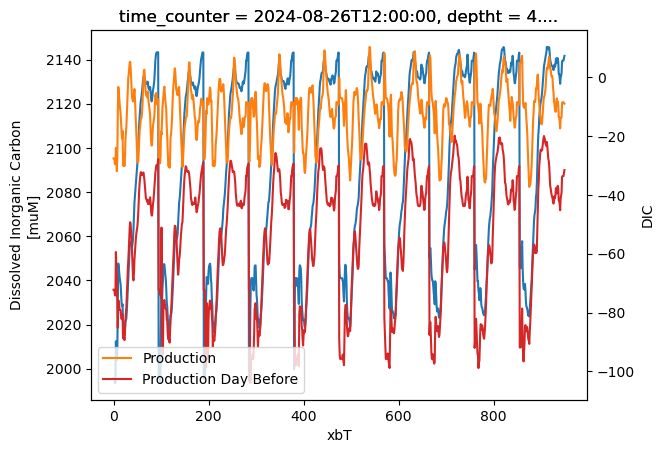

In [60]:
plot_comparison(old, old_daybefore, new, 'DIC', 4)

RMSD, New - Production 6.3890115370089156
RMSD, New - Production Day Before 14.511210915714928


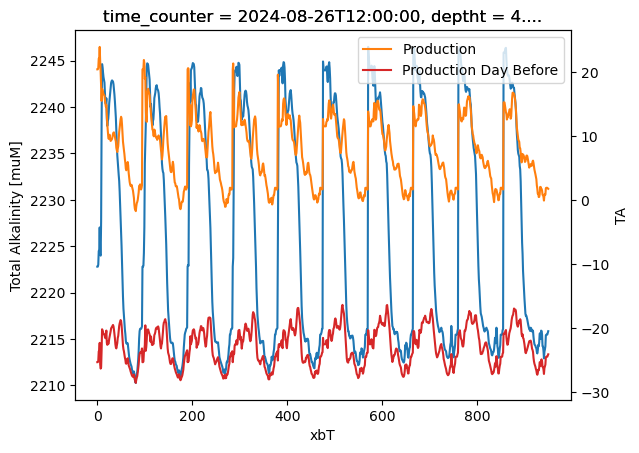

In [61]:
plot_comparison(old, old_daybefore, new, 'TA', 4)